# CNN Training Experiments — Intel Image Classification

Eksperimen pelatihan 16 arsitektur CNN dengan variasi:
- Jumlah layer konvolusi, filter, kernel size, pooling type

> **Google Colab version** — dataset via `kagglehub`, model & hasil ke Google Drive.

In [2]:
# 0. Pastikan GPU aktif — Runtime → Change runtime type → GPU
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✅ GPU ditemukan: {len(gpus)} device(s)")
    for g in gpus:
        print(f"   {g}")
else:
    print("⚠️  GPU tidak tersedia — pastikan runtime type = GPU")

print(f"TensorFlow: {tf.__version__}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")

✅ GPU ditemukan: 1 device(s)
   PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow: 2.20.0
Built with CUDA: True


In [17]:
# 1. Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/CNN_Experiments'
MODEL_DIR  = os.path.join(DRIVE_BASE, 'models')
RESULT_DIR = os.path.join(DRIVE_BASE, 'results')

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print(f"📁 Model dir  : {MODEL_DIR}")
print(f"📁 Result dir : {RESULT_DIR}")

ValueError: Mountpoint must not already contain files

In [4]:
# 2. Import library
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import json, itertools, os
from pathlib import Path
from datetime import datetime

print("✅ Import selesai")

✅ Import selesai


In [ ]:
# 3. Download Intel Image Classification dari Kaggle

try:
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
    print("✅ Kaggle credentials dimuat dari Colab Secrets")
except Exception:
    print("⚠️  Set KAGGLE_USERNAME & KAGGLE_KEY di Colab Secrets atau upload kaggle.json")

import kagglehub
DATASET_PATH = Path(kagglehub.dataset_download("puneet6060/intel-image-classification"))
print(f"\n✅ Dataset: {DATASET_PATH}")
for p in sorted(DATASET_PATH.iterdir()):
    print(f"  {p.name}")

✅ Kaggle credentials dimuat dari Colab Secrets
Using Colab cache for faster access to the 'intel-image-classification' dataset.

✅ Dataset: /kaggle/input/intel-image-classification
  seg_pred
  seg_test
  seg_train


In [6]:
# 4. Konfigurasi path & ukuran gambar
IMG_SIZE    = (150, 150)
CHANNELS    = 3
RANDOM_SEED = 42

train_dir = DATASET_PATH / 'seg_train' / 'seg_train'
test_dir  = DATASET_PATH / 'seg_test'  / 'seg_test'

for d, label in [(train_dir, 'train'), (test_dir, 'test')]:
    if d.exists():
        classes = [x.name for x in sorted(d.iterdir()) if x.is_dir()]
        print(f"✅ {label:5s}: {d}")
        print(f"   classes: {classes}")
    else:
        print(f"❌ {label} dir tidak ditemukan: {d}")

✅ train: /kaggle/input/intel-image-classification/seg_train/seg_train
   classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
✅ test : /kaggle/input/intel-image-classification/seg_test/seg_test
   classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
# 5. Load dataset menggunakan custom batch_loader via tf.data generator
from PIL import Image

def image_loader(path, h=128, w=128):
    im = Image.open(path).convert('RGB')  # pastikan selalu 3 channel
    if h is not None and w is not None:
        im = im.resize((w, h))
    im_arr = np.array(im, dtype=np.float32)
    min_val, max_val = im_arr.min(), im_arr.max()
    if max_val > min_val:
        im_arr = (im_arr - min_val) / (max_val - min_val)
    return im_arr

def batch_loader(paths, h=128, w=128, c=3):
    batch_array = np.zeros((len(paths), h, w, c), dtype=np.float32)
    for idx, path in enumerate(paths):
        img = image_loader(path, h, w)
        if c == 1 and len(img.shape) == 2:
            img = np.expand_dims(img, axis=-1)
        elif c == 3 and len(img.shape) == 2:
            img = np.stack([img, img, img], axis=-1)
        batch_array[idx] = img[:h, :w, :c]
    return batch_array

def collect_paths_and_labels(directory):
    """Kumpulkan path & label tanpa load gambar."""
    directory = Path(directory)
    class_folders = sorted([d for d in directory.iterdir() if d.is_dir()])
    class_names = [d.name for d in class_folders]

    all_paths, all_labels = [], []
    for class_idx, class_folder in enumerate(class_folders):
        image_paths = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
            image_paths.extend(class_folder.glob(ext))
            image_paths.extend(class_folder.glob(ext.upper()))
        image_paths = sorted([str(p) for p in image_paths])
        print(f"  {class_folder.name}: {len(image_paths)} images")
        all_paths.extend(image_paths)
        all_labels.extend([class_idx] * len(image_paths))

    return all_paths, np.array(all_labels, dtype=np.int32), class_names

def make_tf_dataset(paths, labels, img_size=(128,128), batch_size=32, shuffle=False):
    """Buat tf.data.Dataset yang load gambar on-the-fly pakai batch_loader."""
    CHUNK = 64  # load gambar per chunk di dalam map

    def load_image_tf(path, label):
        img = tf.numpy_function(
            func=lambda p: image_loader(p.decode(), h=img_size[0], w=img_size[1]),
            inp=[path],
            Tout=tf.float32
        )
        img.set_shape([img_size[0], img_size[1], 3])
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=RANDOM_SEED)
    ds = ds.map(load_image_tf, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

print("Collecting train paths...")
train_paths, y_train_full, class_names = collect_paths_and_labels(train_dir)

print("\nCollecting test paths...")
test_paths, y_test, _ = collect_paths_and_labels(test_dir)

num_classes = len(class_names)
print(f"\n✅ Train: {len(train_paths)} | Test: {len(test_paths)} | Classes: {class_names}")

  buildings: 2191 images
  forest: 2271 images
  glacier: 2404 images
  mountain: 2512 images
  sea: 2274 images
  street: 2382 images

  buildings: 437 images
  forest: 474 images
  glacier: 553 images
  mountain: 525 images
  sea: 510 images
  street: 501 images

✅ Train: 14034 | Test: 3000 | Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [8]:
# 6. Split train → train + validation
from sklearn.model_selection import train_test_split

train_paths = np.array(train_paths)

X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    train_paths, y_train_full,
    test_size=0.2, random_state=RANDOM_SEED, stratify=y_train_full
)

print(f"Train      : {len(X_train_paths)} images")
print(f"Validation : {len(X_val_paths)} images")
print(f"Test       : {len(test_paths)} images")

Train      : 11227 images
Validation : 2807 images
Test       : 3000 images


In [9]:
# 7. Grid hyperparameter (16 kombinasi)
HYPERPARAMS = {
    'num_conv_layers': [2, 3],
    'filters'        : [[32, 64], [64, 128]],
    'kernel_size'    : [(3, 3), (5, 5)],
    'pooling_type'   : ['max', 'average']
}

experiments = [
    {'num_conv_layers': nl, 'filters': f, 'kernel_size': k, 'pooling_type': p}
    for nl, f, k, p in itertools.product(
        HYPERPARAMS['num_conv_layers'],
        HYPERPARAMS['filters'],
        HYPERPARAMS['kernel_size'],
        HYPERPARAMS['pooling_type']
    )
]

print(f"Total experiments: {len(experiments)}")
for i, exp in enumerate(experiments):
    print(f"  {i+1:2d}. {exp}")

Total experiments: 16
   1. {'num_conv_layers': 2, 'filters': [32, 64], 'kernel_size': (3, 3), 'pooling_type': 'max'}
   2. {'num_conv_layers': 2, 'filters': [32, 64], 'kernel_size': (3, 3), 'pooling_type': 'average'}
   3. {'num_conv_layers': 2, 'filters': [32, 64], 'kernel_size': (5, 5), 'pooling_type': 'max'}
   4. {'num_conv_layers': 2, 'filters': [32, 64], 'kernel_size': (5, 5), 'pooling_type': 'average'}
   5. {'num_conv_layers': 2, 'filters': [64, 128], 'kernel_size': (3, 3), 'pooling_type': 'max'}
   6. {'num_conv_layers': 2, 'filters': [64, 128], 'kernel_size': (3, 3), 'pooling_type': 'average'}
   7. {'num_conv_layers': 2, 'filters': [64, 128], 'kernel_size': (5, 5), 'pooling_type': 'max'}
   8. {'num_conv_layers': 2, 'filters': [64, 128], 'kernel_size': (5, 5), 'pooling_type': 'average'}
   9. {'num_conv_layers': 3, 'filters': [32, 64], 'kernel_size': (3, 3), 'pooling_type': 'max'}
  10. {'num_conv_layers': 3, 'filters': [32, 64], 'kernel_size': (3, 3), 'pooling_type': 'aver

In [10]:
# 8. Model builder
def build_cnn_model(input_shape, num_classes, config):
    model = keras.Sequential(name=f"cnn_{config['num_conv_layers']}layers")
    model.add(layers.Input(shape=input_shape))

    for i in range(config['num_conv_layers']):
        nf = config['filters'][min(i, len(config['filters']) - 1)]
        model.add(layers.Conv2D(nf, config['kernel_size'],
                                padding='same', activation='relu',
                                name=f'conv_{i+1}'))
        if config['pooling_type'] == 'max':
            model.add(layers.MaxPooling2D((2, 2), name=f'maxpool_{i+1}'))
        else:
            model.add(layers.AveragePooling2D((2, 2), name=f'avgpool_{i+1}'))

    model.add(layers.GlobalAveragePooling2D(name='global_pool'))
    model.add(layers.Dense(128, activation='relu', name='dense_1'))
    model.add(layers.Dropout(0.5, name='dropout'))
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))
    return model

In [11]:
# 9. Training configuration
BATCH_SIZE    = 64
EPOCHS        = 10
LEARNING_RATE = 0.001

print(f"Batch size    : {BATCH_SIZE}")
print(f"Max epochs    : {EPOCHS}")
print(f"Learning rate : {LEARNING_RATE}")
print(f"Model dir     : {MODEL_DIR}")
print(f"Result dir    : {RESULT_DIR}")

Batch size    : 64
Max epochs    : 10
Learning rate : 0.001
Model dir     : /content/drive/MyDrive/CNN_Experiments/models
Result dir    : /content/drive/MyDrive/CNN_Experiments/results


In [ ]:
def ensure_drive_mounted():
    """Remount Drive jika terputus."""
    if not os.path.exists('/content/drive/MyDrive'):
        print("⚠️  Drive terputus, remounting...")
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True)
        print("✅ Drive berhasil remount")
    else:
        pass

In [ ]:
results = []
checkpoint_json = os.path.join(RESULT_DIR, 'results_checkpoint.json')

ensure_drive_mounted()

if os.path.exists(checkpoint_json):
    with open(checkpoint_json) as f:
        results = json.load(f)
    done_ids = {r['experiment_id'] for r in results}
    print(f"↩️  Lanjut dari checkpoint: {len(results)} eksperimen selesai")
    print(f"   Done: {sorted(done_ids)}")
else:
    done_ids = set()
    print("⚠️  Checkpoint tidak ditemukan, mulai dari awal")
    print(f"   Path dicari: {checkpoint_json}")

↩️  Lanjut dari checkpoint: 6 eksperimen selesai
   Done: [1, 2, 3, 4, 5, 6]


In [ ]:
# 10. Training loop
# Setiap model disimpan dalam DUA format:
#   .keras  — format modern TF/Keras
#   .h5     — format legacy, untuk kompatibilitas

results = []
checkpoint_json = os.path.join(RESULT_DIR, 'results_checkpoint.json')

if os.path.exists(checkpoint_json):
    with open(checkpoint_json) as f:
        results = json.load(f)
    done_ids = {r['experiment_id'] for r in results}
    print(f"↩️  Lanjut dari checkpoint: {len(results)} eksperimen selesai")
else:
    done_ids = set()

for idx, config in enumerate(experiments):
    exp_id = idx + 1
    if exp_id in done_ids:
        print(f"⏭️  Exp {exp_id} sudah selesai, skip.")
        continue

    print(f"\n{'='*80}")
    print(f"Experiment {exp_id}/{len(experiments)}  |  {config}")
    print(f"{'='*80}\n")

    model_name      = f"model_{exp_id:02d}"
    model_keras_path = os.path.join(MODEL_DIR, f"{model_name}.keras")
    model_h5_path    = os.path.join(MODEL_DIR, f"{model_name}.h5")

    model = build_cnn_model((*IMG_SIZE, CHANNELS), num_classes, config)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    if exp_id == 1:
        model.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
        keras.callbacks.ModelCheckpoint(
            filepath=model_keras_path,
            monitor='val_loss', save_best_only=True,
            verbose=0),
    ]

    start_time = datetime.now()
    train_ds = make_tf_dataset(X_train_paths, y_train,
                              img_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True)
    val_ds   = make_tf_dataset(X_val_paths, y_val,
                              img_size=IMG_SIZE, batch_size=BATCH_SIZE)

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=callbacks, verbose=1
    )
    training_time = (datetime.now() - start_time).total_seconds()

    # Evaluasi
    test_ds = make_tf_dataset(test_paths, y_test,
                              img_size=IMG_SIZE, batch_size=BATCH_SIZE)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    y_pred_classes = np.argmax(model.predict(test_ds, verbose=0), axis=1)

    f1_macro       = f1_score(y_test, y_pred_classes, average='macro')

    # Simpan .h5
    ensure_drive_mounted()
    model.save(model_h5_path)

    # Simpan history eksperimen
    history_path = os.path.join(RESULT_DIR, f"{model_name}_history.json")
    with open(history_path, 'w') as f:
        json.dump({k: [float(v) for v in vals]
                   for k, vals in history.history.items()}, f, indent=2)

    result = {
        'experiment_id'   : exp_id,
        'model_name'      : model_name,
        'config'          : {
            'num_conv_layers': config['num_conv_layers'],
            'filters'        : config['filters'],
            'kernel_size'    : list(config['kernel_size']),
            'pooling_type'   : config['pooling_type'],
        },
        'test_accuracy'   : float(test_acc),
        'test_loss'       : float(test_loss),
        'f1_macro'        : float(f1_macro),
        'training_time_sec': training_time,
        'num_params'      : int(model.count_params()),
        'best_epoch'      : len(history.history['loss']),
        'best_val_loss'   : float(min(history.history['val_loss'])),
        'best_val_acc'    : float(max(history.history['val_accuracy'])),
    }
    results.append(result)

    # Checkpoint
    with open(checkpoint_json, 'w') as f:
        json.dump(results, f, indent=2)

    print(f"\n✅ Exp {exp_id}: acc={test_acc:.4f} | loss={test_loss:.4f} | "
          f"F1={f1_macro:.4f} | {training_time:.1f}s")
    print(f"   💾 {model_keras_path}")
    print(f"   💾 {model_h5_path}")
    print(f"   💾 {history_path}")

    keras.backend.clear_session()

print(f"\n{'='*80}")
print("✅ Semua eksperimen selesai!")
print(f"{'='*80}")

↩️  Lanjut dari checkpoint: 6 eksperimen selesai
⏭️  Exp 1 sudah selesai, skip.
⏭️  Exp 2 sudah selesai, skip.
⏭️  Exp 3 sudah selesai, skip.
⏭️  Exp 4 sudah selesai, skip.
⏭️  Exp 5 sudah selesai, skip.
⏭️  Exp 6 sudah selesai, skip.

Experiment 7/16  |  {'num_conv_layers': 2, 'filters': [64, 128], 'kernel_size': (5, 5), 'pooling_type': 'max'}

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step - accuracy: 0.3987 - loss: 1.4059 - val_accuracy: 0.5137 - val_loss: 1.1788 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 135ms/step - accuracy: 0.4897 - loss: 1.1765 - val_accuracy: 0.5479 - val_loss: 1.0855 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 140ms/step - accuracy: 0.5356 - loss: 1.0999 - val_accuracy: 0.5757 - val_loss: 1.0476 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - accuracy: 0.5658 - loss: 1.0526 - val_accuracy: 0.6071 - val_loss: 0.9798 - learning_rate: 0.0010
Epoch 5/10
176/176 ━━━━━━━━━━━━━


✅ Exp 7: acc=0.7090 | loss=0.7935 | F1=0.7089 | 311.1s
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_07.keras
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_07.h5
   💾 /content/drive/MyDrive/CNN_Experiments/results/model_07_history.json

Experiment 8/16  |  {'num_conv_layers': 2, 'filters': [64, 128], 'kernel_size': (5, 5), 'pooling_type': 'average'}

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 132ms/step - accuracy: 0.3780 - loss: 1.4493 - val_accuracy: 0.5119 - val_loss: 1.1833 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.5052 - loss: 1.1786 - val_accuracy: 0.5565 - val_loss: 1.1139 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.5481 - loss: 1.1190 - val_accuracy: 0.5387 - val_loss: 1.0879 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 0.5700 - loss: 1.0647 - val_accuracy: 0.6163 - val_loss: 0.9732 - learning_rate: 0.0010
Epoc


✅ Exp 8: acc=0.6680 | loss=0.8488 | F1=0.6644 | 205.8s
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_08.keras
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_08.h5
   💾 /content/drive/MyDrive/CNN_Experiments/results/model_08_history.json

Experiment 9/16  |  {'num_conv_layers': 3, 'filters': [32, 64], 'kernel_size': (3, 3), 'pooling_type': 'max'}

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - accuracy: 0.3902 - loss: 1.3806 - val_accuracy: 0.5155 - val_loss: 1.1269 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.5000 - loss: 1.1195 - val_accuracy: 0.5946 - val_loss: 0.9905 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.5817 - loss: 0.9843 - val_accuracy: 0.6291 - val_loss: 0.9172 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.6296 - loss: 0.9174 - val_accuracy: 0.6587 - val_loss: 0.8491 - learning_rate: 0.0010
Epoch 5/10
1


✅ Exp 9: acc=0.7490 | loss=0.6625 | F1=0.7444 | 195.4s
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_09.keras
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_09.h5
   💾 /content/drive/MyDrive/CNN_Experiments/results/model_09_history.json

Experiment 10/16  |  {'num_conv_layers': 3, 'filters': [32, 64], 'kernel_size': (3, 3), 'pooling_type': 'average'}

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - accuracy: 0.3748 - loss: 1.4345 - val_accuracy: 0.4549 - val_loss: 1.2645 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.4845 - loss: 1.2146 - val_accuracy: 0.5761 - val_loss: 1.0808 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - accuracy: 0.5463 - loss: 1.1078 - val_accuracy: 0.5771 - val_loss: 1.0643 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.5857 - loss: 1.0313 - val_accuracy: 0.6295 - val_loss: 0.9296 - learning_rate: 0.0010
Epoch


✅ Exp 10: acc=0.6987 | loss=0.7716 | F1=0.6907 | 191.4s
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_10.keras
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_10.h5
   💾 /content/drive/MyDrive/CNN_Experiments/results/model_10_history.json

Experiment 11/16  |  {'num_conv_layers': 3, 'filters': [32, 64], 'kernel_size': (5, 5), 'pooling_type': 'max'}

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 123ms/step - accuracy: 0.3882 - loss: 1.3995 - val_accuracy: 0.4859 - val_loss: 1.1615 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.5090 - loss: 1.1312 - val_accuracy: 0.5287 - val_loss: 1.1242 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - accuracy: 0.6076 - loss: 0.9731 - val_accuracy: 0.5892 - val_loss: 0.9658 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.6462 - loss: 0.9019 - val_accuracy: 0.6758 - val_loss: 0.8281 - learning_rate: 0.0010
Epoch 5/1

...


✅ Exp 12: acc=0.7633 | loss=0.6227 | F1=0.7631 | 182.6s
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_12.keras
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_12.h5
   💾 /content/drive/MyDrive/CNN_Experiments/results/model_12_history.json

Experiment 13/16  |  {'num_conv_layers': 3, 'filters': [64, 128], 'kernel_size': (3, 3), 'pooling_type': 'max'}

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 33s 148ms/step - accuracy: 0.4018 - loss: 1.3605 - val_accuracy: 0.5194 - val_loss: 1.0976 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 122ms/step - accuracy: 0.5283 - loss: 1.0825 - val_accuracy: 0.5803 - val_loss: 0.9730 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.6059 - loss: 0.9655 - val_accuracy: 0.6598 - val_loss: 0.8858 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 22s 127ms/step - accuracy: 0.6519 - loss: 0.8769 - val_accuracy: 0.6779 - val_loss: 0.8087 - learning_rate: 0.0010
Epoch 


✅ Exp 13: acc=0.7557 | loss=0.6190 | F1=0.7584 | 264.2s
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_13.keras
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_13.h5
   💾 /content/drive/MyDrive/CNN_Experiments/results/model_13_history.json

Experiment 14/16  |  {'num_conv_layers': 3, 'filters': [64, 128], 'kernel_size': (3, 3), 'pooling_type': 'average'}

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 125ms/step - accuracy: 0.3985 - loss: 1.3923 - val_accuracy: 0.5002 - val_loss: 1.1752 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - accuracy: 0.5313 - loss: 1.1355 - val_accuracy: 0.5835 - val_loss: 1.0154 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - accuracy: 0.5826 - loss: 1.0288 - val_accuracy: 0.6277 - val_loss: 0.9456 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.6190 - loss: 0.9441 - val_accuracy: 0.6762 - val_loss: 0.8515 - learning_rate: 0.0010
Epo


✅ Exp 14: acc=0.7477 | loss=0.6686 | F1=0.7414 | 186.3s
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_14.keras
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_14.h5
   💾 /content/drive/MyDrive/CNN_Experiments/results/model_14_history.json

Experiment 15/16  |  {'num_conv_layers': 3, 'filters': [64, 128], 'kernel_size': (5, 5), 'pooling_type': 'max'}

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 46s 216ms/step - accuracy: 0.4166 - loss: 1.3115 - val_accuracy: 0.5119 - val_loss: 1.1822 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 160ms/step - accuracy: 0.5416 - loss: 1.0803 - val_accuracy: 0.5672 - val_loss: 1.0767 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 160ms/step - accuracy: 0.6102 - loss: 0.9612 - val_accuracy: 0.6177 - val_loss: 0.9302 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step - accuracy: 0.6366 - loss: 0.9047 - val_accuracy: 0.7260 - val_loss: 0.7646 - learning_rate: 0.0010
Epoch 


✅ Exp 15: acc=0.8190 | loss=0.4996 | F1=0.8198 | 306.1s
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_15.keras
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_15.h5
   💾 /content/drive/MyDrive/CNN_Experiments/results/model_15_history.json

Experiment 16/16  |  {'num_conv_layers': 3, 'filters': [64, 128], 'kernel_size': (5, 5), 'pooling_type': 'average'}

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 31s 155ms/step - accuracy: 0.3941 - loss: 1.4132 - val_accuracy: 0.5237 - val_loss: 1.1507 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 149ms/step - accuracy: 0.5154 - loss: 1.1590 - val_accuracy: 0.5290 - val_loss: 1.1187 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.5728 - loss: 1.0516 - val_accuracy: 0.6056 - val_loss: 1.0090 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 134ms/step - accuracy: 0.5977 - loss: 1.0124 - val_accuracy: 0.6594 - val_loss: 0.9128 - learning_rate: 0.0010
Ep


✅ Exp 16: acc=0.7907 | loss=0.5904 | F1=0.7921 | 299.1s
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_16.keras
   💾 /content/drive/MyDrive/CNN_Experiments/models/model_16.h5
   💾 /content/drive/MyDrive/CNN_Experiments/results/model_16_history.json

✅ Semua eksperimen selesai!


In [ ]:
# 11. Simpan ke CSV & JSON
results_df = pd.DataFrame(results)
config_df  = pd.json_normalize(results_df['config'])
results_df = pd.concat([results_df.drop('config', axis=1), config_df], axis=1)

csv_path  = os.path.join(RESULT_DIR, 'experiment_results.csv')
json_path = os.path.join(RESULT_DIR, 'experiment_results.json')

results_df.to_csv(csv_path, index=False)
print(f"✅ CSV  : {csv_path}")

with open(json_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f"✅ JSON : {json_path}")

results_df

✅ CSV  : /content/drive/MyDrive/CNN_Experiments/results/experiment_results.csv
✅ JSON : /content/drive/MyDrive/CNN_Experiments/results/experiment_results.json


,experiment_id,model_name,test_accuracy,test_loss,f1_macro,training_time_sec,num_params,best_epoch,best_val_loss,best_val_acc,num_conv_layers,filters,kernel_size,pooling_type
0,1,model_01,0.697333,0.787356,0.696523,212.410156,28486,10,0.793668,0.699679,2,"[32, 64]","[3, 3]",max
1,2,model_02,0.644333,0.938328,0.630996,176.817638,28486,10,0.921807,0.651585,2,"[32, 64]","[3, 3]",average
2,3,model_03,0.693000,0.809015,0.687355,194.768833,62790,10,0.819518,0.690417,2,"[32, 64]","[5, 5]",max
3,4,model_04,0.661333,0.885503,0.650550,189.589022,62790,10,0.880131,0.657642,2,"[32, 64]","[5, 5]",average
4,5,model_05,0.690667,0.806682,0.685535,208.380917,92934,10,0.816118,0.685429,2,"[64, 128]","[3, 3]",max
5,6,model_06,0.692000,0.806382,0.685957,185.218344,92934,10,0.805967,0.690773,2,"[64, 128]","[3, 3]",average
6,7,model_07,0.709000,0.793500,0.708868,311.071355,227078,10,0.799730,0.695404,2,"[64, 128]","[5, 5]",max
7,8,model_08,0.668000,0.848803,0.664371,205.774812,227078,10,0.834436,0.667260,2,"[64, 128]","[5, 5]",average
8,9,model_09,0.749000,0.662546,0.744373,195.434246,65414,10,0.684448,0.751336,3,"[32, 64]","[3, 3]",max
9,10,model_10,0.698667,0.771621,0.690707,191.431259,65414,10,0.783105,0.695404,3,"[32, 64]","[3, 3]",average


Top 5 Models by Macro F1-Score:
 experiment_id  f1_macro  test_accuracy  num_conv_layers   filters kernel_size pooling_type
            15  0.819792       0.819000                3 [64, 128]      [5, 5]          max
            11  0.798122       0.797333                3  [32, 64]      [5, 5]          max
            16  0.792097       0.790667                3 [64, 128]      [5, 5]      average
            12  0.763133       0.763333                3  [32, 64]      [5, 5]      average
            13  0.758414       0.755667                3 [64, 128]      [3, 3]          max


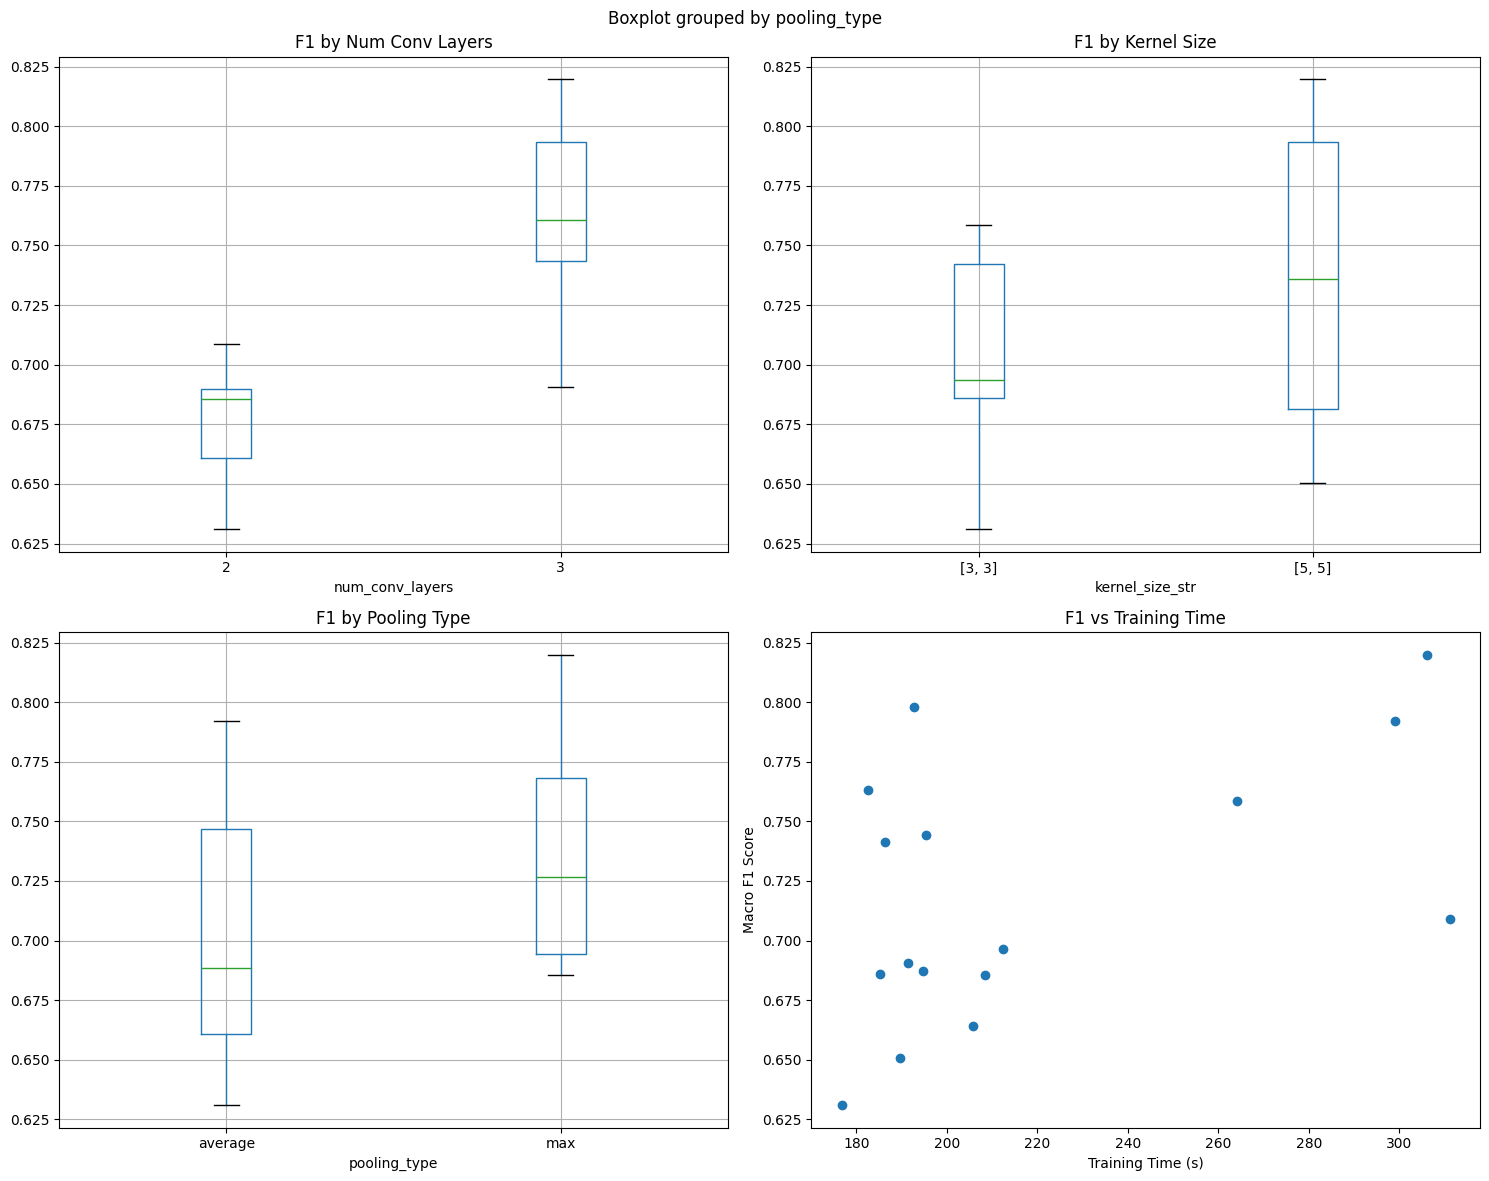

✅ Plot disimpan: /content/drive/MyDrive/CNN_Experiments/results/experiment_analysis.png


In [32]:
# 12. Analisis & Visualisasi
results_sorted = results_df.sort_values('f1_macro', ascending=False)

print("Top 5 Models by Macro F1-Score:")
print(results_sorted[[
    'experiment_id', 'f1_macro', 'test_accuracy',
    'num_conv_layers', 'filters', 'kernel_size', 'pooling_type'
]].head().to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

results_df.boxplot(column='f1_macro', by='num_conv_layers', ax=axes[0, 0])
axes[0, 0].set_title('F1 by Num Conv Layers')

results_df['kernel_size_str'] = results_df['kernel_size'].astype(str)
results_df.boxplot(column='f1_macro', by='kernel_size_str', ax=axes[0, 1])
axes[0, 1].set_title('F1 by Kernel Size')

results_df.boxplot(column='f1_macro', by='pooling_type', ax=axes[1, 0])
axes[1, 0].set_title('F1 by Pooling Type')

axes[1, 1].scatter(results_df['training_time_sec'], results_df['f1_macro'])
axes[1, 1].set_title('F1 vs Training Time')
axes[1, 1].set_xlabel('Training Time (s)')
axes[1, 1].set_ylabel('Macro F1 Score')

plt.tight_layout()
fig_path = os.path.join(RESULT_DIR, 'experiment_analysis.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Plot disimpan: {fig_path}")

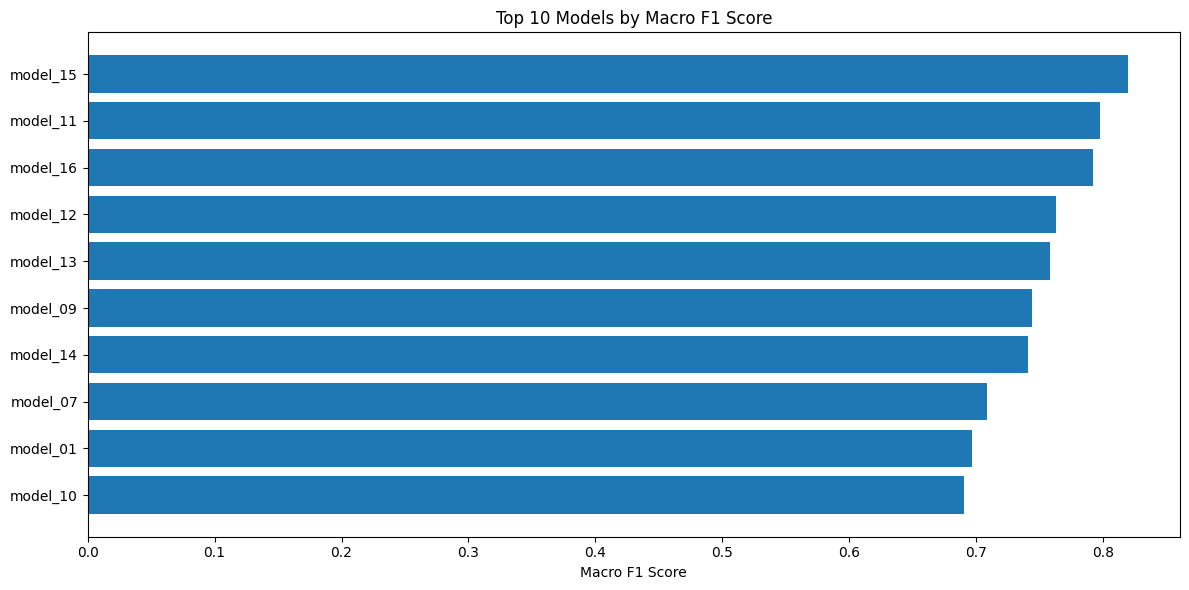

✅ Plot disimpan: /content/drive/MyDrive/CNN_Experiments/results/top_models.png


In [33]:
plt.figure(figsize=(12, 6))
top_10 = results_sorted.head(10)
plt.barh(top_10['model_name'], top_10['f1_macro'])
plt.xlabel('Macro F1 Score')
plt.title('Top 10 Models by Macro F1 Score')
plt.gca().invert_yaxis()
plt.tight_layout()
bar_path = os.path.join(RESULT_DIR, 'top_models.png')
plt.savefig(bar_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Plot disimpan: {bar_path}")

In [34]:
# 13. Summary statistik
print("="*80)
print("EXPERIMENT SUMMARY")
print("="*80)
print(f"Total experiments : {len(results_df)}")
print(f"\nF1 Statistics:")
print(f"  Mean : {results_df['f1_macro'].mean():.4f}")
print(f"  Std  : {results_df['f1_macro'].std():.4f}")
print(f"  Min  : {results_df['f1_macro'].min():.4f}")
print(f"  Max  : {results_df['f1_macro'].max():.4f}")

best = results_sorted.iloc[0]
print(f"\nBest Model: {best['model_name']}")
print(f"  F1       : {best['f1_macro']:.4f}")
print(f"  Accuracy : {best['test_accuracy']:.4f}")
print(f"  Layers   : {best['num_conv_layers']}")
print(f"  Filters  : {best['filters']}")
print(f"  Kernel   : {best['kernel_size']}")
print(f"  Pooling  : {best['pooling_type']}")

print("\nRata-rata per num_conv_layers:")
print(results_df.groupby('num_conv_layers')['f1_macro'].agg(['mean','std']).round(4))
print("\nRata-rata per pooling_type:")
print(results_df.groupby('pooling_type')['f1_macro'].agg(['mean','std']).round(4))
print("\nRata-rata per kernel_size:")
print(results_df.groupby('kernel_size_str')['f1_macro'].agg(['mean','std']).round(4))

EXPERIMENT SUMMARY
Total experiments : 16

F1 Statistics:
  Mean : 0.7199
  Std  : 0.0556
  Min  : 0.6310
  Max  : 0.8198

Best Model: model_15
  F1       : 0.8198
  Accuracy : 0.8190
  Layers   : 3
  Filters  : [64, 128]
  Kernel   : [5, 5]
  Pooling  : max

Rata-rata per num_conv_layers:
                   mean     std
num_conv_layers                
2                0.6763  0.0257
3                0.7635  0.0403

Rata-rata per pooling_type:
                mean     std
pooling_type                
average       0.7024  0.0572
max           0.7374  0.0516

Rata-rata per kernel_size:
                   mean     std
kernel_size_str                
[3, 3]           0.7042  0.0418
[5, 5]           0.7355  0.0658


In [39]:
# 14. Load & evaluasi model terbaik
best_model_name  = results_sorted.iloc[0]['model_name']
best_keras_path  = os.path.join(MODEL_DIR, f"{best_model_name}.keras")
best_h5_path     = os.path.join(MODEL_DIR, f"{best_model_name}.h5")

if os.path.exists(best_keras_path):
    best_model = keras.models.load_model(best_keras_path)
    print(f"✅ Loaded (.keras): {best_keras_path}")
elif os.path.exists(best_h5_path):
    best_model = keras.models.load_model(best_h5_path)
    print(f"✅ Loaded (.h5): {best_h5_path}")
else:
    raise FileNotFoundError(f"Model {best_model_name} tidak ditemukan di {MODEL_DIR}")

best_model.summary()

y_pred         = best_model.predict(test_ds, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

✅ Loaded (.keras): /content/drive/MyDrive/CNN_Experiments/models/model_15.keras


Model: "cnn_3layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 150, 150, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 75, 75, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 37, 37, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling2D)        │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,910,420 (7.29 MB)

 Trainable params: 636,806 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,273,614 (4.86 MB)


Classification Report (Best Model):
              precision    recall  f1-score   support

   buildings       0.70      0.88      0.78       437
      forest       0.96      0.95      0.96       474
     glacier       0.83      0.73      0.78       553
    mountain       0.78      0.80      0.79       525
         sea       0.78      0.88      0.83       510
      street       0.91      0.69      0.78       501

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.83      0.82      0.82      3000

